# Credit Card Default Prediction: Exploratory Data Analysis

Author: Samantha Fish

Date: March 2026

Tools Used: Python, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn

Techniques: EDA, Cross-Validation, Logistic Regression, Random Forest, Gradient Boosting, Grid Search Hyperparameter Tuning, ROC-AUC Evaluation, Prediction-Recall Evaluation

## Executive Summary

This project develops machine learning models to predict whether a credit card client will default on their payment in the following month. Using the UCI Credit Card Default dataset containing 30,000 observations, three different models were trained and evaluated, including Logistic Regression, Random Forest, and Gradient Boosting. Gradient Boosting achieved the best performance with a cross-validated ROC-AUC of approximately 0.7813.

The results show that repayment history variables are the strongest predictors of default risk, particularly the most recent payment status (PAY_0). While the model demonstrates strong overall predictive ability with accuracy and ROC-AUC, recall remains relatively low at the default classification threshold, highlighting the importance of threshold selection in real-world credit risk applications. These findings can help to understand how machine learning can support financial institutions in identifying clients at risk of defaulting while balancing precision trade-offs and business risk considerations.

## Introduction

The objective of this project is to analyze the UCI Credit Card Default Dataset and identify patterns associated with default credit risk. The target variable is `default payment next month`, which is a binary categorical variable wherein 0 indicates no default and 1 indicates default. 

Using this dataset, this project applies several machine learning techniques including Logistic Regression, Random Forest, and Gradient Boosting to model and predict whether a borrower will default on their credit card payment in the following month. The analysis focuses on understanding the structure of the dataset, evaluating and comparing different predictive models, then assessing model performance using appropriate evaluation metrics for imbalanced classification problems.

## Dataset
**Source:** UCI Credit Card Dataset: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients 

Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.

**Observations:** 30,000

**Target Variable:** `default payment next month`

## Libraries

In [131]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Data Loading

The dataset is loaded from the raw data directory. The original file is kept unchanged to preserve the source data.

In [132]:
df = pd.read_excel("../data/default of credit card clients.xls", header=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Dataset Overview

This project uses the Default of Credit Card Clients dataset from the UCI Machine Learning Repository. The dataset contains information on 30,000 credit card clients and includes demographic characteristics, financial data, and repayment behavior over the previous six months.

The dataset consists of 25 variables, including features such as credit limit, bill amounts, payment amounts, and repayment status for previous months. Demographic variables such as age, sex, education level, and marital status are also included.

The target variable, "default payment next month", indicates whether the client defaulted on their credit card payment in the following month, wherein 1 = Default and 0 = No Default. The goal of this project is to analyze patterns within the dataset and build models capable of predicting this outcome.

We begin by examining the basic structure of the dataset, including the number of observations/rows, number of features/columns, data types, and summary statistics.

In [133]:
pd.set_option("display.max_columns", None)
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Initial Observations

- Dataset contains 30000 rows and 25 columns.
- All variables are stored as integers and there are no missing values.
- Several variables are categorical but encoded numerically, including SEX, EDUCATION, and MARRIAGE.
- ID should be treated as a unique identifier, not numeric, and thus will likely be removed during preprocessing.
- Repayment status variables (PAY_0 through PAY_6) represent the payment status for the previous months and are ordinal categorical variables indicating levels of payment delay.
- Financial variables such as BILL_AMT1 through BILL_AMT6 represent monthly bill statements, while PAY_AMT1 through PAY_AMT6 represent the individual's payment amounts for each month.
- The column "default payment next month" represents the target variable, indicating whether the client defaulted on their credit card payment in the following month.
- Financial variables such as credit limits, bill amounts, and payment amounts show large ranges and standard deviations, suggesting substantial variation across customers. 
- Potential outliers in financial variables as the maximum credit limit, bill amount, and payment amount are far from the mean even accounting for standard deviation.
- The average client age appears to be in the mid-30s, with a range spanning from early 20s to more elderly individuals approaching 80.
- A large portion of variables include historical variables of past payments and bill amounts, which likely will be relevant to predicting whether an individual will default. 
    - Among these historical variables, there is a 6 month history included for variables such as PAY, PAY_AMT, and BILL_AMT wherein 1 (or 0 for PAY) indicates the value from the previous month and 6 indicates the value of this variable from 6 months ago.


### Variable Definitions

Several variables in the dataset are encoded numerically but represent categorical information.

- **SEX**
  - 1 = male
  - 2 = female

- **EDUCATION**
  - 1 = graduate school
  - 2 = university
  - 3 = high school
  - 4 = other
  - 0, 5, 6 = unknown or miscellaneous categories

- **MARRIAGE**
  - 1 = married
  - 2 = single
  - 3 = other
  - 0 = unknown


- **PAY_0 through PAY_6**
  Repayment status in previous months, with 0 being last month and 6 being 6 months ago.

  - -2 = no consumption
  - -1 = paid in full
  - 0 = paid on time
  - 1–9 = payment delay (number of months late)


These variables will be treated as categorical during preprocessing, with the exception of PAY_0 through PAY_6 which will be treated as ordinal as they indicate increasing levels of payment delay.

## Exploratory Data Analysis

This exploratory data analysis will assess data quality, the distribution of the dataset and its features, potential class imbalances, and relationships with the target variable of `default payment next month`.


### Target Variable Distribution 

Before modeling, it is important to examine the distribution of the target variable `default payment next month` to determine whether class imbalance exists. 

In [134]:
df['default payment next month'].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [135]:
df['default payment next month'].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

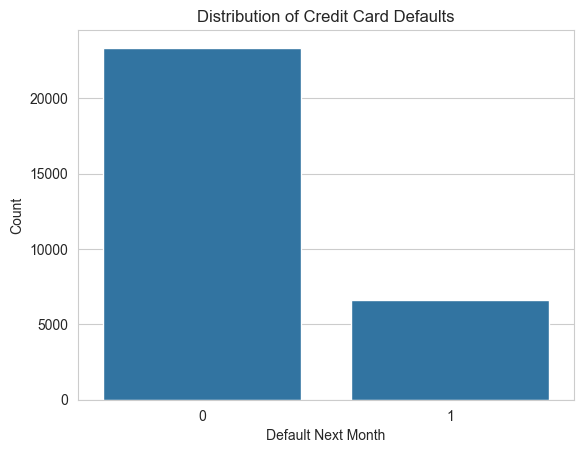

In [136]:
sns.countplot(x='default payment next month', data=df)
plt.title("Distribution of Credit Card Defaults")
plt.xlabel("Default Next Month")
plt.ylabel("Count")
plt.show()

### Target Variable Distribution

The dataset shows moderate class imbalance. Approximately 78% of clients did not default, while about 22% defaulted on their credit card payment the following month. Due to this imbalance, accuracy alone may not fully reflect model performance as solely assuming not default would be correct almost 80% of the time. Additional metrics such as precision, recall, and F1-score may provide better insight into how well the model can identify and predict default cases.

### Categorical Feature Distributions

The following plots examine the distribution of categorical variables in the dataset to better understand the demographic characteristics of the clients.

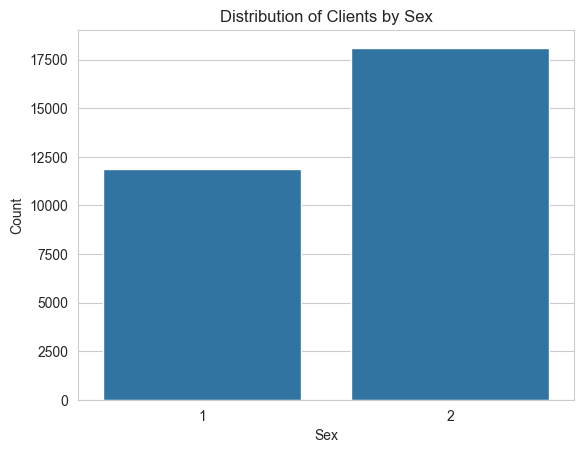

In [137]:
sns.countplot(x='SEX', data=df)
plt.title("Distribution of Clients by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

The dataset contains both male and female clients, with a slightly larger proportion of female clients.

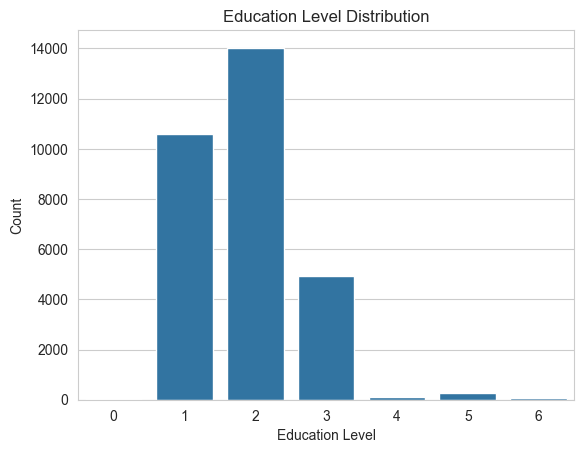

In [138]:
sns.countplot(x='EDUCATION', data=df)
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

The majority of clients have university or graduate-level education, while fewer individuals from the dataset fall into the high school level or other categories. 

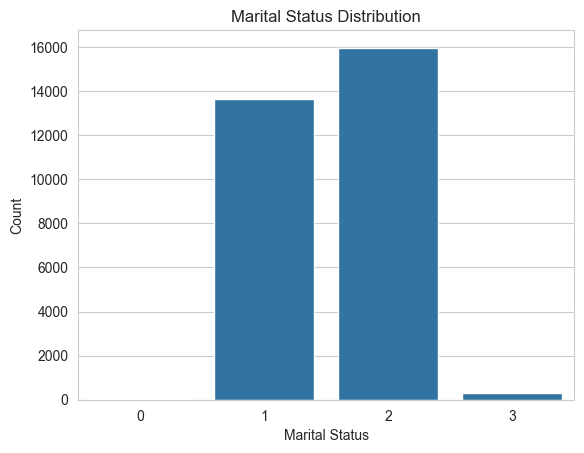

In [139]:
sns.countplot(x='MARRIAGE', data=df)
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

There's a roughly equal proportion of clients who are married and single, though slightly more individuals fall into the single category. Very few observations fall outside of these two categories into other or unknown status.

## Categorical vs Default

Now these categorical variables will be plotted against the target variable. 

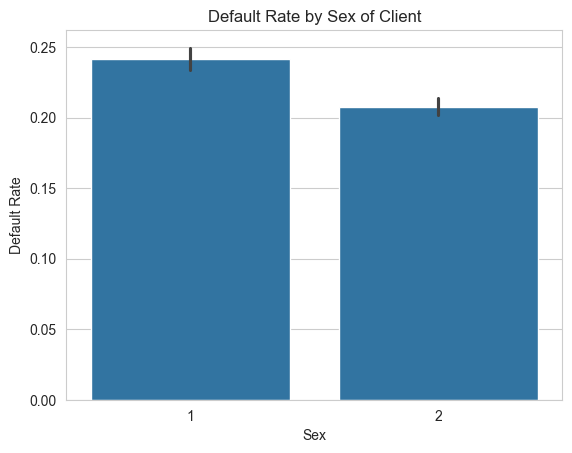

In [140]:
sns.barplot(
    x='SEX',
    y='default payment next month',
    data=df
)

plt.title("Default Rate by Sex of Client")
plt.xlabel("Sex")
plt.ylabel("Default Rate")
plt.show()

Default rates appear slightly higher among male clients than female clients. However, the difference is relatively modest, suggesting that sex alone may not be a strong predictor of default behavior.

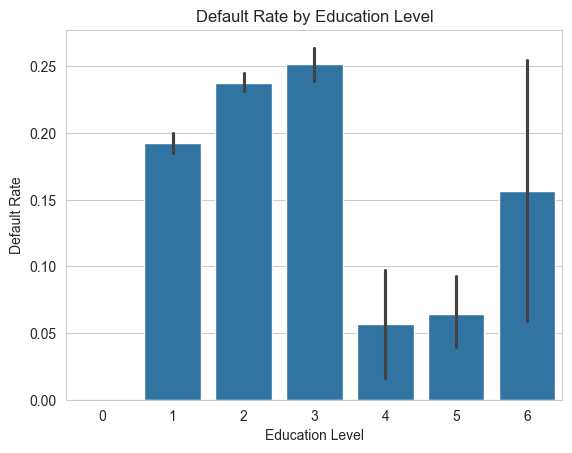

In [141]:
sns.barplot(
    x='EDUCATION',
    y='default payment next month',
    data=df
)

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate")
plt.show()

Default rates appear to vary somewhat across education levels. Clients with high school or university education exhibit slightly higher default rates compared to those with graduate-level education. 

However, categories such as "other" or unknown education levels show very low default rates, which may reflect small sample sizes or irregular category coding in the dataset. This is also emphasized by much wider confidence intervals, implying uncertainty for the levels that previously were discovered to have much fewer observations.

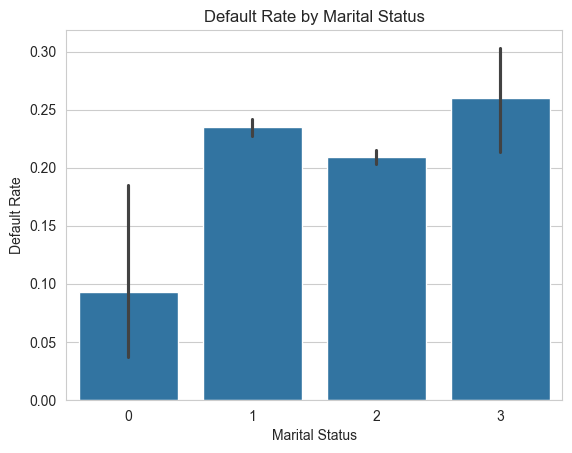

In [142]:
sns.barplot(
    x='MARRIAGE',
    y='default payment next month',
    data=df
)

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate")
plt.show()

Default rates appear slightly higher among married clients compared to single clients, though the difference is relatively small. In the other and unknown categories, the default rate varies wildly, however there is uncertainty as shown through the much larger confidence intervals due to the smaller number of observations in these groups. Overall, marital status does not appear to be the strongest predictor of default risk.

### Numerical Feature Distribution

The following plots examine the distributions of key numerical variables in the dataset, including credit limits and age.

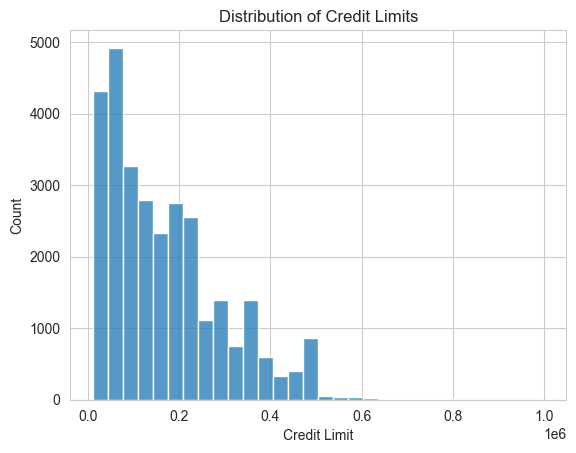

In [143]:
sns.histplot(df['LIMIT_BAL'], bins=30)
plt.title("Distribution of Credit Limits")
plt.xlabel("Credit Limit")
plt.show()

Credit limits appear to be right-skewed, with most clients having lower to moderate credit limits and fewer clients possessing very high limits that create a long right tail.

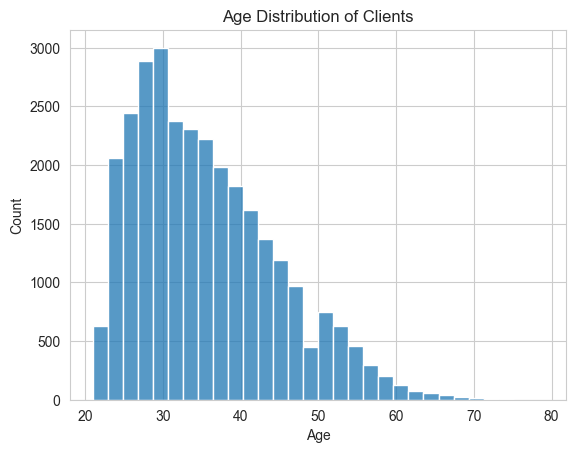

In [144]:
sns.histplot(df['AGE'], bins=30)
plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.show()

The age distribution is centered around the mid-30s, with most clients falling between their late 20s and mid-40s. The age distribution appears to be slightly right-skewed by older clients. The minimum age appears to be 21, suggesting that clients younger than this are not included in the dataset.

### Financial Behavior vs Default Risk

Now the numerical and ordinal financial variables will be plotted against default risk.

Text(0.5, 1.0, 'Previous Month Payment Status by Default Value')

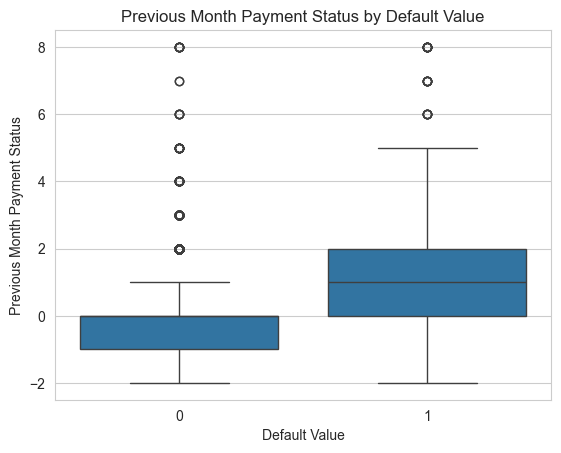

In [145]:
sns.boxplot(x='default payment next month', y='PAY_0', data=df)
plt.xlabel("Default Value")
plt.ylabel("Previous Month Payment Status")
plt.title("Previous Month Payment Status by Default Value")

Repayment status in the previous month appears strongly associated with default behavior. Clients who do not default typically have repayment statuses between -1 or 0, indicating full payment or on-time payment. However, clients who default tend to have higher repayment delay values, often indicating 1 or more months of delayed payments. This suggests that recent repayment history may be a particularly important predictor of default risk.

Text(0.5, 1.0, 'Credit Limit Distribution by Default Status')

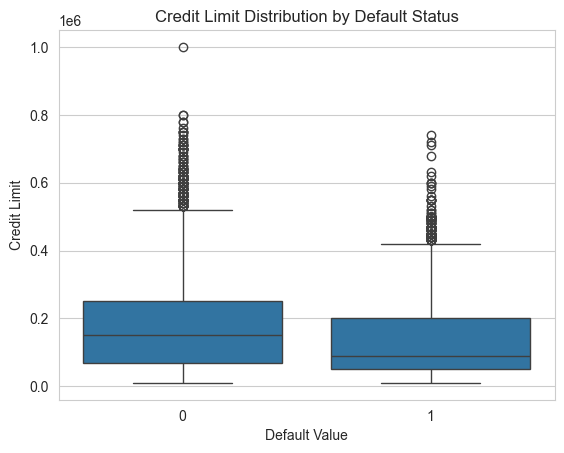

In [146]:
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.xlabel("Default Value")
plt.ylabel("Credit Limit")
plt.title("Credit Limit Distribution by Default Status")

Credit limits appear slightly higher among clients who do not default. 
Clients who default tend to have somewhat lower credit limits on average, 
though there is a considerable overlap between the two groups. This suggests that while credit limit may be related to default risk to some degree, it is likely a weaker predictor compared to repayment history variables.

Text(0.5, 1.0, 'Previous Month Bill Amount by Default Status')

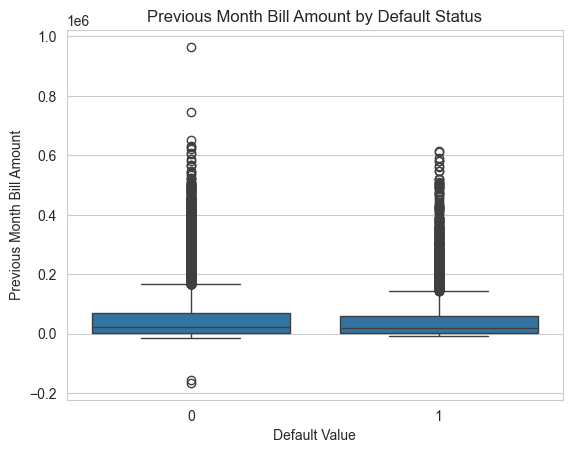

In [147]:
sns.boxplot(x='default payment next month', y='BILL_AMT1', data=df)
plt.xlabel("Default Value")
plt.ylabel("Previous Month Bill Amount")
plt.title("Previous Month Bill Amount by Default Status")

Bill amounts in the previous month appear relatively similar between clients who default and those who do not. Both groups show highly right-skewed distributions with many large outliers. This suggests that the raw bill amount alone may not be a strong indicator of default behavior without considering repayment patterns or other variables.

Text(0.5, 1.0, 'Previous Month Payment Amount by Default Status')

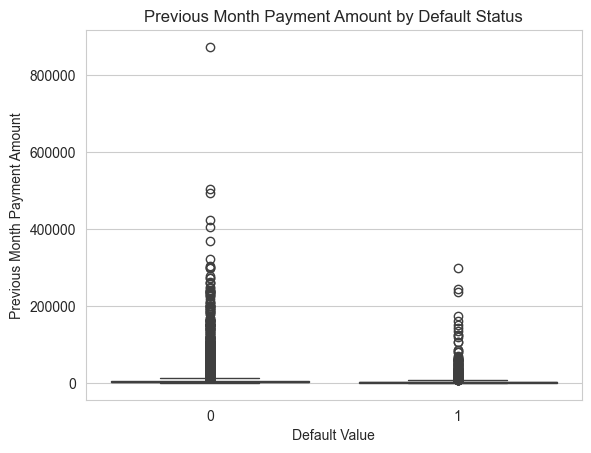

In [148]:
sns.boxplot(x='default payment next month', y='PAY_AMT1', data=df)
plt.xlabel("Default Value")
plt.ylabel("Previous Month Payment Amount")
plt.title("Previous Month Payment Amount by Default Status")

Clients who do not default generally appear to make slightly larger payment amounts compared to those who default. However, the distributions remain highly right-skewed and overlapping, indicating that payment amounts alone may not be a strong indicator of default behavior without considering other indicators like repayment status variables.

### Correlation Analysis

To better understand relationships between variables in the dataset, a correlation matrix is examined. Correlation measures how strongly two variables are related. This can help identify which data features move together and which variables may provide useful predictive signals for default risk.

A heatmap visualization is used to display the correlations between variables. Warmer colors indicate stronger positive correlations, while cooler colors indicate negative correlations. Values close to zero suggest little to no linear relationship.

Text(0.5, 1.0, 'Correlation Matrix of Credit Default Dataset')

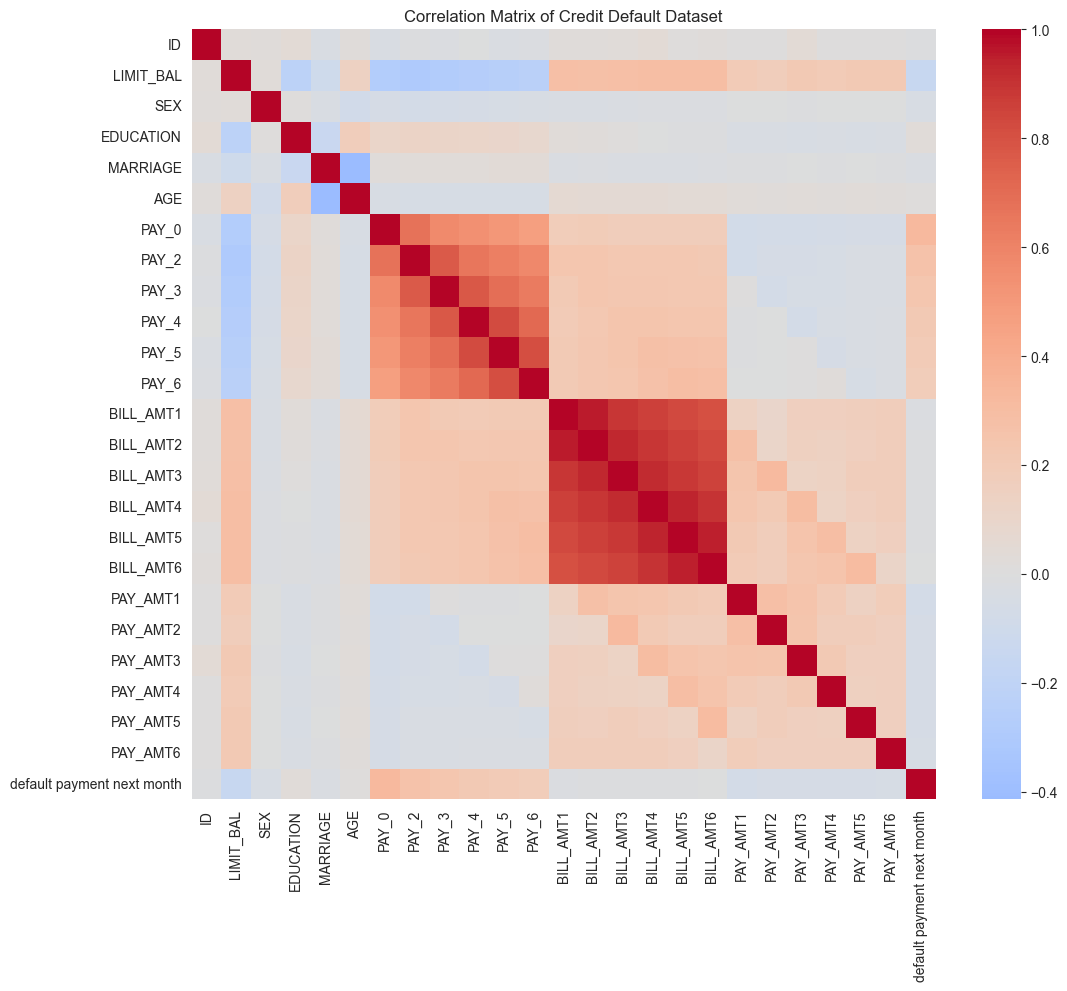

In [149]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Credit Default Dataset")

The correlation matrix reveals clear clusters among groups of related variables. Repayment status variables (PAY_X) show moderate to strong correlations across months, suggesting that payment behavior tends to persist over time. Similarly, bill amounts (BILL_AMTX) and payment amounts (PAY_AMTX) also display strong correlations across months, reflecting that clients tend to have consistent repayment and spending patterns.

The strongest correlations with the target variable appear among the repayment status variables, particularly recent payment statuses and delays. PAY_0, the most recent previous month's status, shows strongest positive correlation with default status. This supports earlier observations that repayment history may be one of the most important predictors of future default behavior. Meanwhile, demographic variables such as age, sex, education, and marital status show relatively weak correlations with default payment status.

### Key Findings from Exploratory Data Analysis

Several patterns emerged from the exploratory analysis:

- Historical repayment status variables appear strongly associated with default behavior. Clients with recent payment delays are significantly more likely to default.
- Credit limits and payment amounts show some differences between defaulters and non-defaulters, though these relationships seem to be weaker than repayment history.
- Financial variables such as bill amounts and payment amounts show strong correlations across months, reflecting consistent spending and repayment behavior among clients.
- Demographic variables such as age, sex, education, and marital status appear to have relatively weak relationships with default risk.

Overall, repayment history variables appear to be the most important set of predictors for modeling credit default behavior.

## Data Preprocessing

Before training machine learning models, the dataset must be prepared for modeling. This includes separating the target variable from the feature variables to prevent data leakage, removing non-informative or irrelevant columns, and splitting the dataset into training and testing sets. The training set will be used to train the models, while the test set will be used to evaluate model performance on unseen data.

In [150]:
df = df.drop(columns=["ID"])

The ID column is removed because it serves only as a unique identifier and does 
not provide meaningful information for predicting default behavior.

### Feature and Target Separation

In [151]:
X = df.drop(columns=["default payment next month"])
y = df["default payment next month"]

The dataset is separated into feature variables (X) and the target variable (y). 
The target variable represents whether a client defaulted on their payment in 
the following month.

### Train-Test Split

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((24000, 23), (6000, 23))

The dataset is split into training and testing sets using an 80/20 split. 
Stratified sampling of y is used to ensure that the proportion of default (0.22) and 
non-default (0.78) cases remains consistent in both the training and testing datasets.

## Model Development


### Logistic Regression

Logistic regression estimates the probability that an observation belongs to a particular class using a logistic function.

Because logistic regression is affected by differences in feature scale, the features 
are standardized before training the model. Cross-validation is used to evaluate model 
performance on the training data before testing on the held-out test set.

#### Feature Scaling

Logistic regression works best when features are scaled similarly. Since variables in this dataset have very different ranges, like how credit limits can reach hundreds of thousands of dollars while age range falls between roughly 20–80, standardization is applied. This rescales each feature to have mean 0 and standard deviation 1 so they are weighted fairly.

In [153]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Cross-Validation

Cross-validation is used to estimate model performance on the training data before testing how it performs using the test set. The training set is divided into 5 different folds, and the model is trained and validated multiple times. The average score across folds provides a more reliable estimate of performance than a single test-train split.

In [154]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

def evaluate_model(model, X, y, cv=cv):

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    print("Cross-validation ROC-AUC scores:", scores)
    print(f"Mean ROC-AUC: {scores.mean():.4f}")
    print(f"Std ROC-AUC: {scores.std():.4f}")

    return scores.mean()

To simplify repeated model evaluation, a helper function is defined for cross-validation. The function performs 5-fold cross-validation using ROC-AUC as the scoring metric and returns the mean score across folds. Stratified k-fold cross-validation with shuffling was used to ensure that each fold maintains the same proportion of defaulters and non-defaulter, reducing potential bias from any ordering of the dataset. This function will also be reused later to evaluate additional models.

For logistic regression, X_train_scaled is used instead of X_train because the algorithm is sensitive to magnitude and features with larger magnitudes such as bill or payment amounts would dominate the model if not standardized. 

To make comparison between models direct, cross-validation scores are stored in a dictionary. This allows the results from the 3 models to be collected and later displayed in a comparison table.

In [155]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)

logistic_score = evaluate_model(
    log_reg,
    X_train_scaled,
    y_train,
)

model_scores: dict = {}
model_scores["Logistic Regression"] = logistic_score

Cross-validation ROC-AUC scores: [0.74122572 0.72742481 0.70961414 0.71863308 0.73368187]
Mean ROC-AUC: 0.7261
Std ROC-AUC: 0.0111


The logistic regression model achieved a mean cross-validated ROC-AUC score of 0.7261 with a standard deviation of 0.0111 across five folds.

A mean cross-validated ROC-AUC score of 0.7261 indicates that the model has decent predictive ability and can moderately distinguish between those who will default and those who will not, and a standard deviation of 0.0111 indicates that the model is very stable across folds and performs consistently. 

Logistic regression serves as a good baseline model due to its simplicity and ease of interpretation, though it depends on linear relationships which can make it rigid for more complex data. More flexible models such as Random Forest or Boost Gradient may capture nonlinear relationships and potentially perform better in predicting the target variable `default payment next month`. 

### Random Forest

Random forests combine many decision trees to improve the model's performance when predicting the target variable and reduce overfitting. Each tree is trained on a different bootstrap sample of the data and considers only a random subset of features when evaluating splits at each node. 

This randomness helps produce diverse trees whose predictions are aggregated, which often outperforms a single decision tree. Unlike logistic regression, random forests can capture interactions between features and relationships with the target variable and do not require feature scaling.

The number of trees (n_estimators) was increased to 200 to improve model stability, as larger ensembles tend to reduce variance and improve predictive ability. Other parameters were left at their default values to establish a baseline model before further tuning.

In [156]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_score = evaluate_model(
    rf,
    X_train,
    y_train
)

model_scores["Random Forest"] = rf_score

Cross-validation ROC-AUC scores: [0.76757357 0.77154478 0.76265833 0.7629319  0.77236624]
Mean ROC-AUC: 0.7674
Std ROC-AUC: 0.0041



The random forest model achieved a mean cross-validated ROC-AUC score of 0.7674 with a standard deviation of 0.0041 across five folds.

A mean ROC-AUC score of 0.7674 indicates moderate-to-strong predictive ability when distinguishing between those who default and those who do not. The mean ROC-AUC is approximately 0.0413 higher than the Logistic Regression Model's baseline, an improvement which suggests that the model benefits from its ability to capture interactions between features and nonlinear relationships with the target variable. However, the relatively small magnitude of the improvement may indicate that the underlying relationships in the data are not strongly nonlinear if the logistic regression model already captures much of the predictive structure. The standard deviation of 0.0041 indicates that the model is very stable across folds and performs consistently. However, while performance improved, the model still leaves room for improvement either by hyperparameter tuning or by using a different ensemble method.

### Gradient Boosting

Gradient boosting is another ensemble learning method that builds models sequentially. Each new tree is trained to correct and minimize the residual errors made by the previous trees by focusing more heavily on the observations that were previously misclassified.

By gradually improving the model through many small trees whose predictions are combined additively for overall performance, gradient boosting can capture more complex patterns in the data and improve predictive ability. However, unlike random forests, gradient boosting models are more sensitive to hyperparameter choices such as the learning rate and number of trees, so hyperparameters must be carefully chosen to prevent overfitting.

The gradient boosting classifier was trained using 300 trees with a learning rate of 0.05 and a maximum tree depth of 3. A relatively small learning rate was chosen to allow the model to learn gradually and reduce the risk of overfitting. Because smaller learning rates require more boosting stages, the number of trees (n_estimators) was increased to 300. The tree depth was limited to 3 to keep individual trees simple and prevent the model from overfitting to noise in the training data.


In [124]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_score = evaluate_model(
    gb,
    X_train,
    y_train
)

model_scores["Gradient Boosting"] = gb_score

Cross-validation ROC-AUC scores: [0.7854865  0.78173306 0.76828034 0.78586367 0.78528932]
Mean ROC-AUC: 0.7813
Std ROC-AUC: 0.0067


The gradient boosting model achieved a mean cross-validated ROC-AUC score of 0.7813 with a standard deviation of 0.0067 across five folds. 

A mean ROC-AUC score of 0.7813 indicates a moderate to good predictively ability when distinguishing between those who will default and those who will not. The gradient boosting model improved mean ROC-AUC by approximately 0.055 compared to logistic regression and 0.014 compared to random forest, performing noticeably better than the logistic model and slightly better than the random forest model. This suggests that the model's ability to capture more complex interactions between features and nonlinear relationships in the data, as well as the ability to sequentially improve upon the error of previous trees, helped to improve predictive performance. A standard deviation of 0.0067 implies that the model is very stable across folds and that it performs consistently. While this model shows the strongest performance so far, the predictive ability of the model could still potentially be improved from hypertuning.  



## Model Comparison

To compare the performance of the 3 different types of models, the mean cross-validated ROC-AUC scores are summarized below. This allows us to evaluate which model has the strongest and most consistent predictive ability and performance across five folds.

In [125]:
results_df = pd.DataFrame.from_dict(
    model_scores,
    orient= "index",
    columns=["Mean ROC-AUC"]
    )

results_df = results_df.sort_values(by="Mean ROC-AUC", ascending=False)
results_df


,Mean ROC-AUC
Gradient Boosting,0.781331
Random Forest,0.767415
Logistic Regression,0.726116


The model comparison chart shows that Gradient Boosting achieved the highest mean cross-validated ROC-AUC score, followed by Random Forest and then Logistic Regression. This result suggests that ensemble tree-based models maintain stronger predictive ability as they capture nonlinear relationships and feature interactions in the data more effectively than the logistic regression baseline. While the improvement over Random Forest is smaller, the performance advantage across the five folds suggests that the sequential boosting approach can produce stronger predictive performance, which is common in tabular data. Because Gradient Boosting demonstrates the strongest predictive performance, it will be selected for further hyperparameter tuning and final evaluation on the test dataset.

## Hyperparameter Tuning (Gradient Boosting)

Hyperparameter tuning is used to improve model performance by finding the combination of model parameters that produces the best predictive performance. For gradient boosting models, important hyperparameters include the number of trees (n_estimators), the learning rate (learning_rate), and the depth of individual trees (max_depth). These parameters control the model's complexity and the rate at which the model learns from the data and fits to it.

GridSearchCV was used to tune the Gradient Boosting model's hyperparameters. The search evaluated combinations of n_estimators, learning_rate, and max_depth using 5-fold cross-validation and ROC-AUC as the evaluation metric. A total of 27 model configurations were tested.

In [126]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_final = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_final,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score (ROC-AUC):", grid_search.best_score_)
print("Best Model:", grid_search.best_estimator_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best CV Score (ROC-AUC): 0.7819142604293188
Best Model: GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                           random_state=42)


The best performing model used 200 trees (n_estimators), a learning rate of 0.05, and a maximum tree depth of 4.

This configuration achieved a mean cross-validated ROC-AUC of 0.7819, indicating good ability to distinguish between customers who default and those who do not.

The moderate learning rate of 0.05 and the maximum tree depth of 4 suggest that the model benefits from more gradual learning and controlled complexity, which helps reduce overfitting while still capturing nonlinear patterns in the data.

## Final Model Evaluation

After selecting the best hyperparameters through cross-validation, the final Gradient Boosting model is evaluated using the held-out test dataset. This step provides an unbiased estimate of the model's real-world performance because the test data was not used during training or hyperparameter tuning, preventing data leakage.

The model performance is evaluated using several classification metrics including accuracy, precision, recall, and ROC-AUC, along with a confusion matrix and ROC curve. The default classification threshhold is 0.5, meaning that the model predicts a default if the estimated probability exceeds 50%, otherwise it predicts no default.

In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Test Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test ROC-AUC:", roc_auc)
print("Proportion of Defaults:", f"{y_test.mean():.4f}")

Test Accuracy: 0.818
Test Precision: 0.6638772663877266
Test Recall: 0.35870384325546345
Test ROC-AUC: 0.7783688495100282
Proportion of Defaults: 0.2212


The final Gradient Boosting model achieved an accuracy of 81.8%, indicating strong overall predictive performance. However, accuracy alone can be misleading in credit default prediction because the dataset was shown to have a class imbalance, with only approximately 22% of observations representing defaults in both the training and test data. Therefore, a model that never predicted default would still have a  78% accuracy despite not offering any meaningful discrimination based on data features.

The model achieved a precision of 66.4%, meaning that when it predicts a borrower will default, it is correct roughly two-thirds of the time.

The recall of 35.9% indicates that the model identifies about one-third of actual defaulters. This relatively low recall suggests that some clients who are at risk of defaulting are not flagged by the model.

The ROC-AUC score of 0.778 indicates good overall ability to distinguish between borrowers who default and those who do not. ROC-AUC provides a more reliable measure of model quality in imbalanced datasets because it evaluates how well the model is able to predict higher risk of defaulting to those who do default rather than relying on a single classification threshold.

In credit risk modeling, ROC-AUC and recall are often particularly important, as they measure how effectively the model identifies risky borrowers and distinguishes them from safe borrowers. It's important to also account for the relative risk of false negatives and false positives; it's often more costly to assume a false negative than a false positive in credit risk modeling, as failing to flag risk for a defaulter can lead to large financial loss. This oftentimes can lead to banks altering the classification threshhold from the default of 0.5 in order to catch more of these cases.

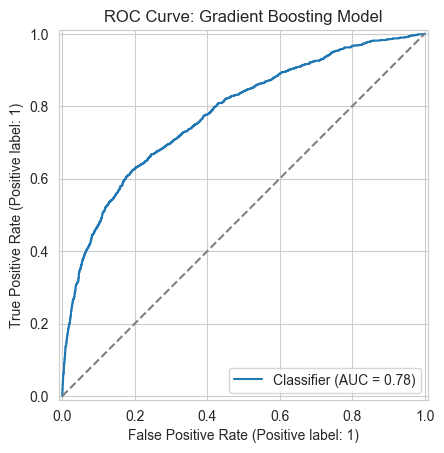

In [128]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve: Gradient Boosting Model")
plt.plot([0,1],[0,1],'--',color='gray')
plt.show()

The ROC curve illustrates the model's ability to distinguish between clients who default and those who do not across different classification thresholds. The curve lies well above the diagonal reference line that represents random guessing, indicating that the model has meaningful predictive power.

The area under the curve (AUC) is approximately 0.78, suggesting that the model has a moderately strong ability to rank borrowers by their risk of default. This means that a randomly selected client who defaults will receive a higher predicted default probability than a randomly selected non-defaulter about 78% of the time.

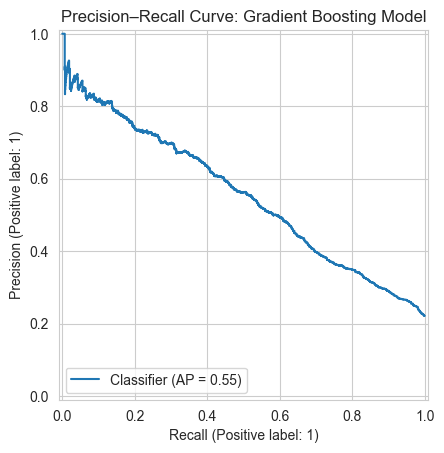

In [129]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)

plt.title("Precision–Recall Curve: Gradient Boosting Model")
plt.show()

The precision–recall curve illustrates the trade-off between identifying more defaulters (recall) and being correct when flagging a potential defaulter (precision) across different classification thresholds. As the threshold decreases, the model flags more borrowers as potential defaulters, which increases recall but reduces precision because more safe borrowers are incorrectly classified as risky.

The model achieves an average precision (AP) score of approximately 0.55. Given that the baseline precision is about 22% due to class imbalance, this indicates that the model provides meaningful improvement over random guessing when identifying borrowers who may default.

In credit risk modeling, recall is often particularly important because failing to identify a borrower who will default (a false negative) can lead to significant financial losses. As a result, financial institutions may choose to lower the classification threshold below the default value of 0.5 in order to increase recall, even if this leads to some reduction in precision.

### Model Limitations and Future Improvements

Limitations

- Threshold sensitivity: Precision/recall depend heavily on the chosen classification threshold. Using the default 0.5 threshold yields relatively low recall, meaning a fair amount of defaulters are passed over.

- Class imbalance: Only ~22% of observations are defaults, so metrics like accuracy can be misleading; the model may perform well overall while still under-detecting the minority class.

- Potential data bias: The model relies on historical credit data, which may contain biases introduced by past lending decisions based upon demographic features such as race, age, etc. Additionally, this dataset could have geographical bias as it is based upon Taiwanese clients and might not generalize well to Europe or the US.

- Unequal error costs: False negatives (missing a real defaulter) can be much more costly than false positives, but the current model evaluation has a classification threshhold of 0.5, weighing both error costs equally.

- Interpretability: Gradient Boosting is less directly interpretable than linear models. Analyzing feature importance can help to some extent, but it does not show the direction of potential effects and may be biased toward variables with many potential node split points.

Future Improvements

- Tune the classification threshold using specific business goals (for example, maximizing recall or another specific metric) rather than defaulting to 0.5.

- Expand the hyperparameter search grid to explore a wider range of model configurations.

- Apply probability calibration so predicted probabilities better reflect true default risk, enabling more meaningful use of risk thresholds beyond a simple default/no-default decision.

- Try a wider variety of alternative models and compare performances.

- Potentially engineer new features (e.g. Payment-Bill Ratio or nonlinear transformations) that could help improve the model's predictive ability, especially if using logistic or linear-based regression methods.

### Feature Importance

Feature importance scores from the Gradient Boosting model are examined to identify which variables contribute most to predicting whether a borrower will default or not. Higher importance values correspond to features that play a larger role in determining default risk.

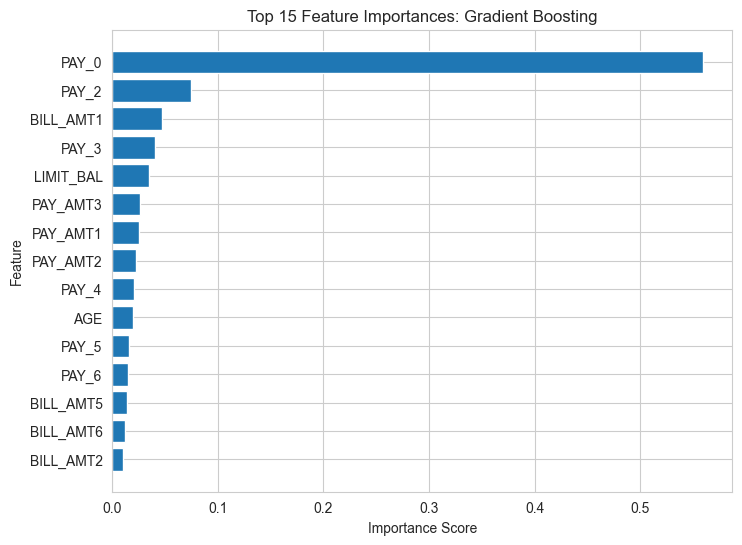

,Feature,Importance
5,PAY_0,0.559107
6,PAY_2,0.074069
11,BILL_AMT1,0.047256
7,PAY_3,0.040882
0,LIMIT_BAL,0.034520
19,PAY_AMT3,0.026595
17,PAY_AMT1,0.025467
18,PAY_AMT2,0.022660
8,PAY_4,0.020444
4,AGE,0.019532


In [130]:

importances = best_model.feature_importances_

fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)


top_n = 15
fi_top = fi.head(top_n).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(fi_top["Feature"], fi_top["Importance"])
plt.title(f"Top {top_n} Feature Importances: Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


fi.head(15)

The feature importance analysis reveals that the borrower's most recent repayment status (PAY_0) is by far the most influential predictor of default risk in the Gradient Boosting model. This variable has significantly higher importance than any other feature, indicating that recent payment behavior very strongly influences the model's predictions. Historical patterns, especially recent, of clients delaying payment seem to be a strong indicator of default risk.

Several other repayment history variables (PAY_2, PAY_3, etc.) also appear among the most important features, suggesting that patterns of past payment history play a significant role in predicting default risk.

Financial variables such as credit limit (LIMIT_BAL) and billing or payment amounts also contribute to the model's predictions but have lower relative importance compared to repayment history. Demographic variables such as age have a relatively small influence, indicating that the model primarily relies on historical financial data when identifying potential defaulters.

The dominance of PAY_0 suggests that the model may rely heavily on recent payment status, which could limit the influence of other financial features.

## Conclusion

This project explored the use of three different machine learning models to predict credit card default risk using the UCI Taiwanese Credit Card client dataset. The analysis began with exploratory data analysis (EDA) to understand the structure of the dataset, identify class imbalance, and examine feature distributions. The dataset contained a binary `default payment next month` target variable indicating whether a borrower defaulted on their credit card payment or not, with a ~22% default rate.

Three different predictive models were implemented and compared, including Logistic Regression, Random Forest, and Gradient Boosting. Cross-validation was used to evaluate model performance on the training data, with ROC-AUC selected as the primary evaluation metric due to the class imbalance in the dataset. Among the models tested, the Gradient Boosting classifier achieved the highest cross-validated mean ROC-AUC score of 0.7813 and was therefore selected as the final model. Gradient Boosting often performs well on tabular data, so this was an expected result. 

Then, after narrowing it down to the Gradient Boosting model, hyperparameter tuning was conducted using grid search to optimize the main key parameters including the number of trees (n_estimators), learning rate, and maximum tree depth. The best performing combination of parameters used 200 estimators, a learning rate of 0.05, and a maximum tree depth of 4.

The final model was evaluated on the held-out test dataset using several metrics, including accuracy, precision, recall, and ROC-AUC. While the model achieved strong overall accuracy (81.8%) and a ROC-AUC score of approximately 0.78, the recall score was relatively low at only 35.9%, indicating that a sizeable portion of defaulters were not identified as a default risk by the model when using the default classification threshold of 0.5. This highlights the importance of considering threshold adjustments in credit risk modeling where recall is often weighed more than precision, because missing a defaulter can be more costly than incorrectly flagging a safe borrower.

Feature importance analysis revealed that repayment history variables were the most influential predictors in the model. In particular, the borrower’s most recent repayment status (PAY_0) was by far the most important feature, suggesting that recent delayed payments are a strong indicator of future default risk. Other repayment history and financial variables such as bill and payment amounts also contributed meaningfully, while demographic variables played a relatively smaller role in model predictions.

Overall, the results demonstrate that machine learning models such as Gradient Boosting can effectively capture patterns in financial behavior to predict default risk. However, model performance depends heavily on classification thresholds, which evaluation metrics are considered to be the the most relevant for real-world credit risk decisions, and the underlying characteristics and patterns of the dataset. Future improvements could include additional feature engineering, expanded hyperparameter tuning, probability calibration, and experimentation with alternative models.